# Post-processing chain

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import scipy as sp
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import patches
from matplotlib.ticker import FuncFormatter
from astropy import units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.plot       as pt
import platosim.starquery  as sq
import platosim.utilities  as ut
import platosim.statistics as st
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

import warnings
warnings.simplefilter("ignore")

In [3]:
# Define paths used throughout
fdir = '/lhome/nicholas/Nextcloud/paperMOCKA/figures'
path = '/lhome/nicholas/software/workdir/mocka'
idir = f'{path}/input'

## *Example of photometry*

In [471]:
# Set up a Simulation object
sim = Simulation("output_photometry", outputDir=os.getcwd())

# Download files from KUL FTP site:
inputDir = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles"
# ut.downloadFromFTP(filename="varsource_gdor.txt",  outputDir=os.getcwd(), server='plato')
# ut.downloadFromFTP(filename="varsource_algol.txt", outputDir=os.getcwd(), server='plato')
# ut.downloadFromFTP(filename="varsource_ap.txt",    outputDir=os.getcwd(), server='plato')

# Load variable source files
variableSourceFile0 = inputDir + "/varsource_gdor.txt"
variableSourceFile1 = inputDir + "/varsource_algol.txt"
variableSourceFile2 = inputDir + "/varsource_ap.txt"

# Load files
var0 = np.loadtxt(variableSourceFile0)
var1 = np.loadtxt(variableSourceFile1)
var2 = np.loadtxt(variableSourceFile2)

<IPython.core.display.Javascript object>


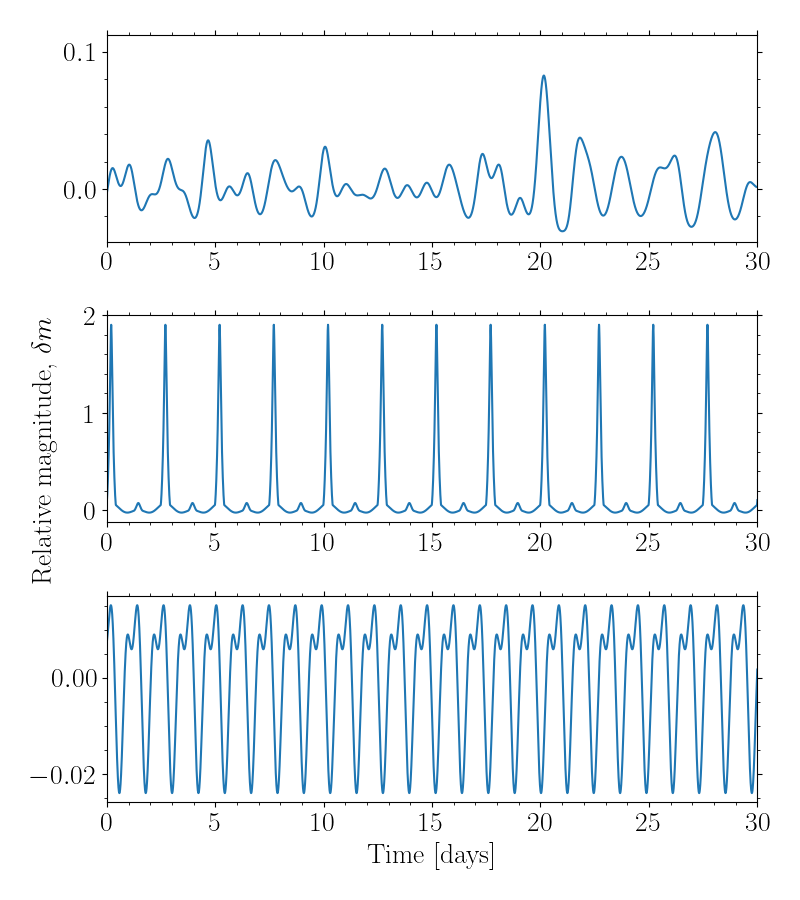

In [472]:
# Show noise-less light curves
fig, ax = plt.subplots(3, 1, figsize=(8,9))
for i, var in zip(range(3), [var0, var1, var2]):
    time = var[:,0]/86400
    ax[i].plot(time, var[:,1])
    ax[i].set_xlim(time[0], 30)
fig.text(0.04, 0.5, 'Relative magnitude, $\delta m$', va='center', rotation='vertical')
ax[2].set_xlabel('Time [days]')
plt.tight_layout()

In [473]:
# Automatic catalogue file creation
starID = [0, 1, 2]
variableSourceFiles = [variableSourceFile0, variableSourceFile1, variableSourceFile2]
variableSourceList  = os.getcwd() + "/varlist_photometry.txt"
sim.createVariableSourceList(starID, variableSourceFiles, variableSourceList)

# Select subfield size and location
sim["SubField/NumColumns"]      = 6
sim["SubField/NumRows"]         = 6
sim["SubField/ZeroPointRow"]    = 3000
sim["SubField/ZeroPointColumn"] = 3000

# Define catalogue
row = np.array([3.0, 2.1, 4.3]) + sim["SubField/ZeroPointRow"]
col = np.array([3.0, 1.8, 5.2]) + sim["SubField/ZeroPointColumn"]
mag = np.array([10.0, 12.0, 11.0])

# Automatic catalogue file creation
starcatFile = os.getcwd() + "/starcat_photometry.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, starID, starcatFile)

# Automatic photometry file creation
starID = [0]
photometryFile = os.getcwd() + "/photometry_example1.txt"
sim.createPhotometryFile(starID, photometryFile)

# Turn off saving 
sim.turnOffAllOutput()
sim["Sky/IncludeCosmicsInSubField"]    = False

# Control HDF5
sim["ControlHDF5Content/GroupByExposure"]    = True
sim["ControlHDF5Content/WritePixelMaps"]     = True
sim["ControlHDF5Content/WriteStarPositions"] = True
sim["ControlHDF5Content/WriteCosmics"]       = True

# Activate photometry
sim["Photometry/IncludePhotometry"] = True
sim["Photometry/TargetFileName"]    = photometryFile

<IPython.core.display.Javascript object>


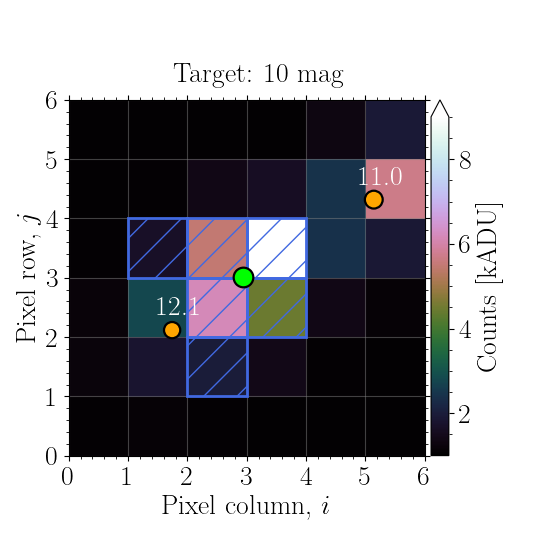

In [478]:
# Show imagette
sim["ObservingParameters/NumExposures"] = 1
f0 = sim.run(removeOutputFile=True)
fig, ax = f0.showImage(imgScale="percentile", clip=1, fontSize=20, count='kADU',
                       figsize=(5.5,5.5), showStarPositions='PIC', origin='lower',
                       colorBar=True, showGrid=True, showMaskOfStarID=0)
# fig.text(0.47, 0.85, 'a) Imagette', ha='center')
fig.text(0.47, 0.85, 'Target: 10 mag', ha='center')
# Save figure
fig.savefig(f'{fdir}/Imagette.png', bbox_inches='tight', dpi=200)

In [9]:
# Run the simulation
sim["ObservingParameters/NumExposures"] = int(10*86400/25.)
f1 = sim.run(removeOutputFile=True, executionTime=True)

Execution time : 0:01:43.497739 [hh:mm:ss]


<IPython.core.display.Javascript object>


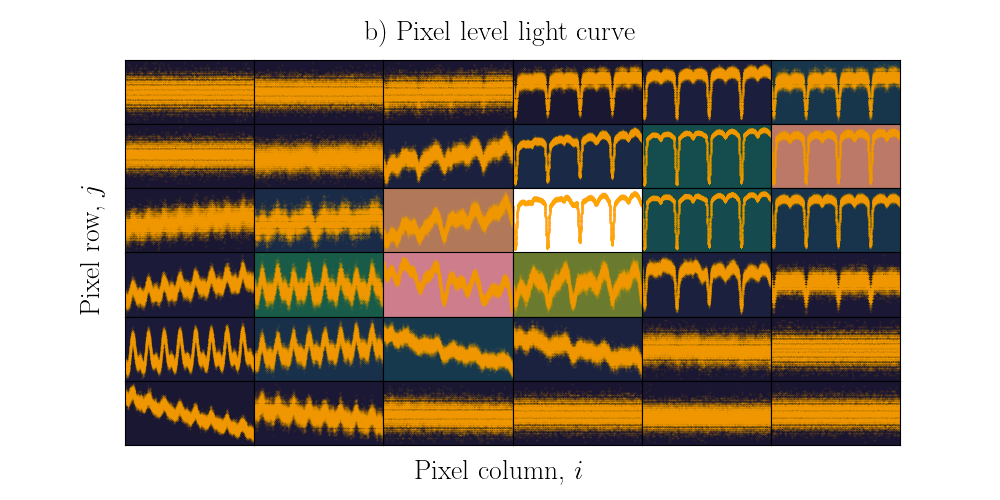

In [11]:
fig = f1.showPixelLevelLightCurve()
fig.text(0.5, 0.92, 'b) Pixel level light curve', ha='center')
# Save figure
fig.savefig(f'{fdir}/PixelLevelLightCurve.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


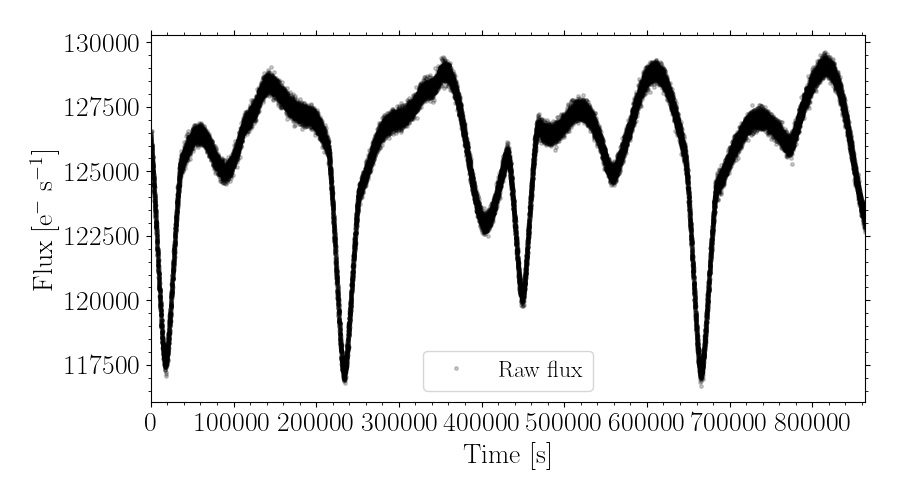

In [12]:
f1.plotLightCurve(0);

## Show light curve

In [176]:
lc = LightCurve(f'{path}/test_local/000000600/000000600_Ncam2.1_Q1.ftr')

In [177]:
lc.varsource()

,time,mag,flux
0,0.0,0.109287,-0.029632
1,25.0,0.109278,-0.029624
2,50.0,0.109270,-0.029617
3,75.0,0.109261,-0.029609
4,100.0,0.109253,-0.029601
...,...,...,...
2522875,63071875.0,0.085976,-0.008572
2522876,63071900.0,0.085977,-0.008574
2522877,63071925.0,0.085979,-0.008576
2522878,63071950.0,0.085981,-0.008577


<IPython.core.display.Javascript object>


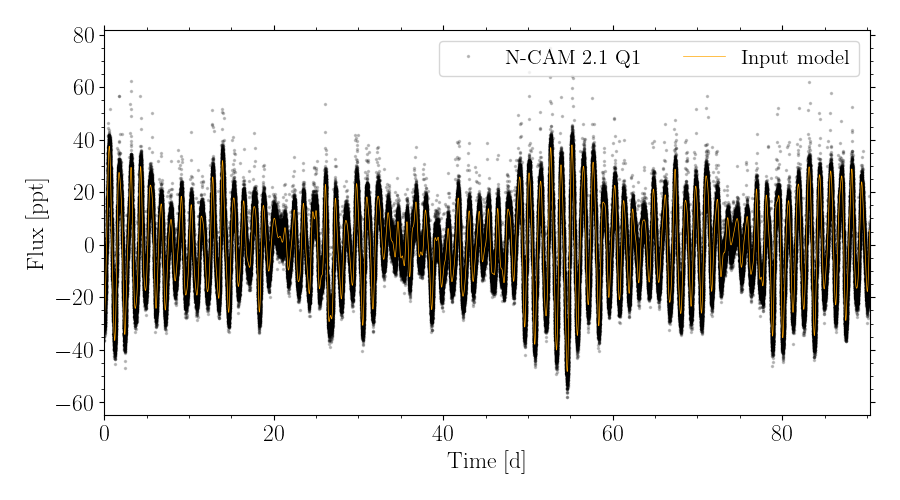

In [181]:
lc.plot(flux_unit='ppt', input_model=True);

## Test model comparison for detrending

In [16]:
filename = f'{path}/test_local/000000001/000000001_Ncam1.1_Q1.hdf5'
# filename = f'{path}/test_local/000000005/000000005_Ncam4.1_Q3.hdf5'
lc = LightCurve(filename)
sim = Simulation('test.hdf5') 
beginExposureNr = int(315569*(int(filename[-6])-1))
numExposures    = 312113

In [17]:
# Data
df = lc.data()
df = df.loc[:int(30*86400/25)]
df = df.rename(columns={'time':'x', 'flux':'y'})

# Test models
model1 = 'y ~ x'
model2 = 'y ~ x + I(x**2)'
model3 = 'y ~ x + I(x**2) + I(x**3)'
fit1 = sm.OLS.from_formula(formula=model1, data=df).fit()
fit2 = sm.OLS.from_formula(formula=model2, data=df).fit()
fit3 = sm.OLS.from_formula(formula=model3, data=df).fit()
fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.167
Model:                            OLS   Adj. R-squared:                  0.167
Method:                 Least Squares   F-statistic:                 2.080e+04
Date:                Wed, 14 Feb 2024   Prob (F-statistic):               0.00
Time:                        16:27:01   Log-Likelihood:            -5.9617e+05
No. Observations:              103681   AIC:                         1.192e+06
Df Residuals:                  103679   BIC:                         1.192e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4195.3472      0.472   8884.192      0.000    4194.422    4196.273
x          -4.551e-05   3.16e-07   -144.232      0.000   -4.61e-05   -4.49e-05
==============================================================================
Omnibus:                   119049.210   Durbin-Watson:                   1.953
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         29703855.050
Skew:                           5.693   Prob(JB):                         0.00
Kurtosis:                      85.135   Cond. No.                     2.99e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.99e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [4]:
# st.plot_modelfit(df, fit1, model1, theme='b');

In [5]:
# st.plot_modelfit(df, fit2, model2, theme='g');

In [6]:
# st.plot_modelfit(df, fit3, model3, theme='r');

In [21]:
AIC_j = [fit1.aic, fit2.aic, fit3.aic]
BIC_j = [fit1.bic, fit2.bic, fit3.bic]
st.model_selection(AIC_j, BIC_j, show=True)


------------------------------
Model comparison
AIC weight model 1: 0.0
BIC proba. model 1: 0.0
AIC weight model 2: 1.0
BIC proba. model 2: 1.0
AIC weight model 3: 0.0
BIC proba. model 3: 0.0

Heuristical likelihood
w1/w2 : 0.0
p1/p2 : 0.0
w2/w3 : inf
p2/p3 : inf
w3/w1 : 0.0
p3/p1 : 0.0

Probability in favour of model 1 over 2
w1/(w1+w2) : 0.0 %
p1/(p1+p2) : 0.0 %

Probability in favour of model 1 over 3
w1/(w1+w3) : 1.0 %
p1/(p1+p3) : 1.0 %

Probability in favour of model 2 over 3
w2/(w2+w3) : 1.0 %
p2/(p2+p3) : 1.0 %
------------------------------



3

## Test of single quarter with mask-updates

In [14]:
# filename = f'{path}/test_local/000000001/000000001_Ncam1.1_Q1.hdf5'
# filename = f'{path}/test_local/000000002/000000002_Ncam1.1_Q1.hdf5'
# filename = f'{path}/test_local/000000003/000000003_Ncam2.1_Q1.hdf5'
# filename = f'{path}/test_local/000000004/000000004_Ncam1.1_Q1.hdf5'
# filename = f'{path}/test_local/000000005/000000005_Ncam2.1_Q1.hdf5'
# filename = f'{path}/test_local/000000005/000000005_Ncam4.1_Q3.hdf5'
filename = f'{path}/test_local/000000005/000000005_Ncam2.1_Q1.hdf5'
# path = '/lhome/nicholas/software/workdir/cs-binary/tests/test0/sims/'
# filename = f'{path}/000000001/000000001_Ncam1.1_Q1.hdf5'

lc = LightCurve(filename)
sim = Simulation('test.hdf5') 
beginExposureNr = int(315569*(int(filename[-6])-1))
numExposures    = 312113

In [15]:
inputFileGap = f'{idir}/instrumentGAP.ftr'
df = lc.gaps(inputFileGap, beginExposureNr, numExposures, replace=True, plot=False)
df

,time,flux
0,12.5,6697.125380
1,37.5,6862.262659
2,62.5,6891.208594
3,87.5,6777.090806
4,112.5,6771.676547
...,...,...
312108,NaN,NaN
312109,NaN,NaN
312110,NaN,NaN
312111,NaN,NaN


In [33]:
# Introduce gaps
df = lc.data()
dg = pd.read_feather(inputFileGap)
dg = dg.iloc[beginExposureNr:beginExposureNr+numExposures]
# df = df.replace(df.loc[~dg['all'].to_numpy()]
df.loc[dg['all']] = np.nan
df

,time,flux
0,12.5,6697.125380
1,37.5,6862.262659
2,62.5,6891.208594
3,87.5,6777.090806
4,112.5,6771.676547
...,...,...
312108,NaN,NaN
312109,NaN,NaN
312110,NaN,NaN
312111,NaN,NaN


<IPython.core.display.Javascript object>


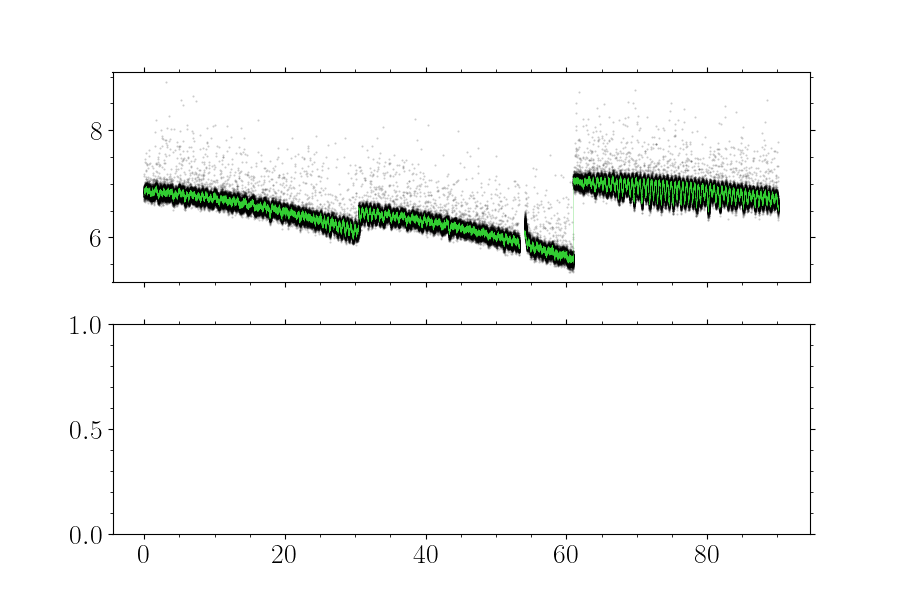

ValueError: Axis limits cannot be NaN or Inf

In [16]:
# Transient correction
inputFileCCD = f'{idir}/instrumentGTT.txt'
dt = pd.read_csv(inputFileCCD, sep=' ', names=['time', 'temp'])
dt = dt.iloc[beginExposureNr:beginExposureNr+numExposures]
temp = dt.temp.to_numpy()
inputFileGap = f'{idir}/instrumentGAP.tab'
dg = pd.read_feather(inputFileGap)
tdur = dg.td.iloc[0] / 86400
tempNominal   = sim['CCD/NominalOperatingTemperature']
gainCCD       = sim['CCD/Gain/RefValueRight']
gainFEE       = sim['FEE/Gain/RefValueRight']
gainStability = sim['FEE/Gain/Stability']
df = lc.correct_gain(temp, tdur, tempNominal, gainCCD, gainFEE, gainStability, replace=True, plot=True)

<IPython.core.display.Javascript object>


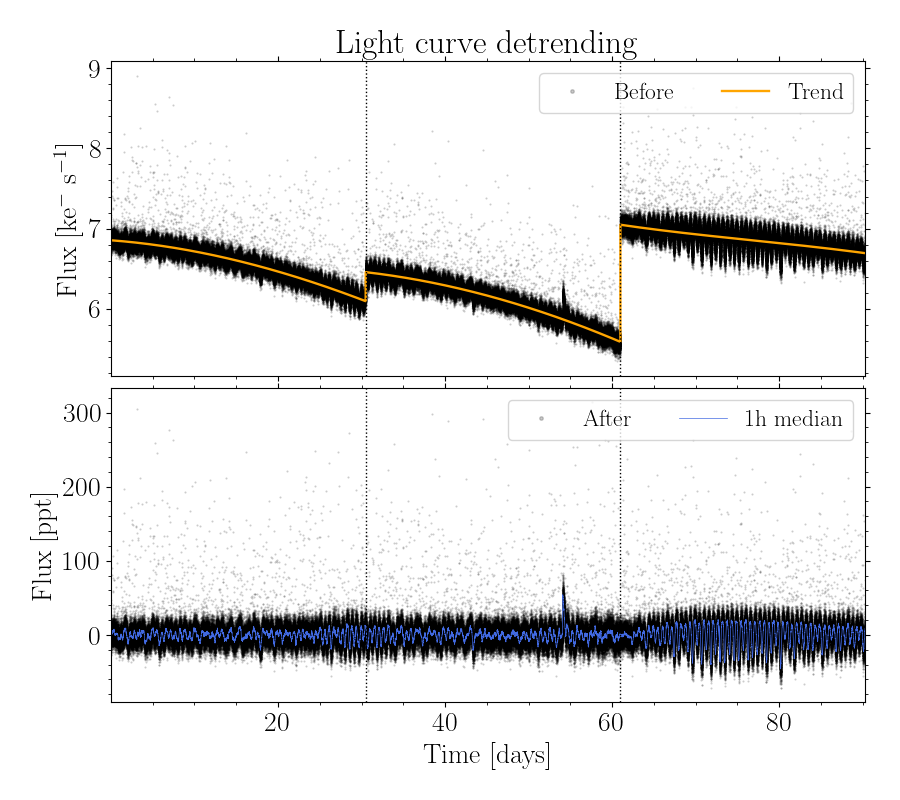

In [11]:
df = lc.detrend(model='poly', replace=True, plot=True)

<IPython.core.display.Javascript object>


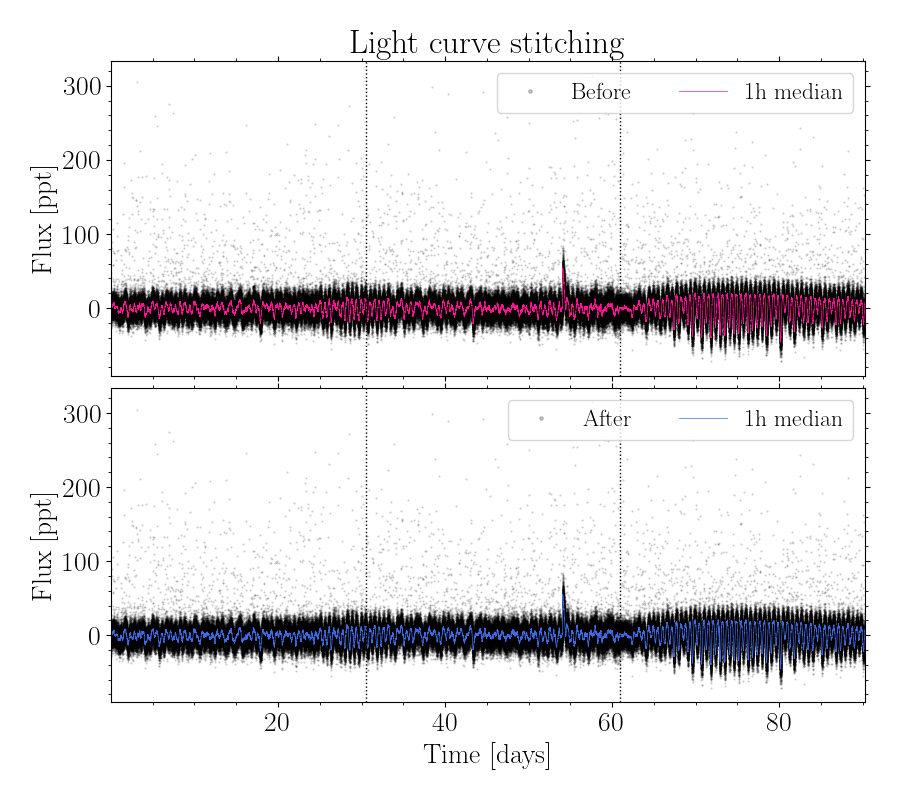

In [12]:
lc.stitch(method='lowess', replace=True, plot=True);

<IPython.core.display.Javascript object>


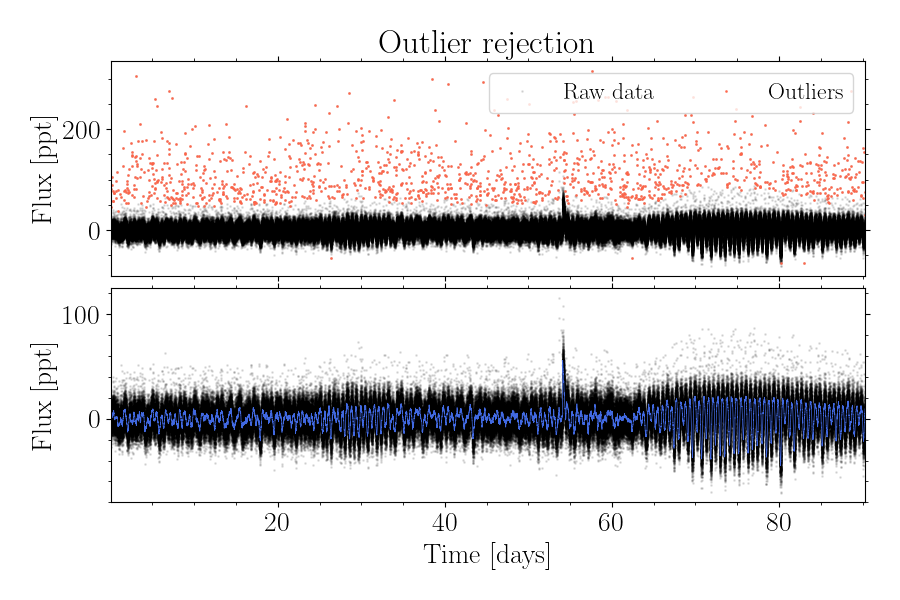

In [13]:
df = lc.clip(model='wotan', replace=True, plot=True, flux_unit='ppt')

## Test light curves merging

In [4]:
lcs = LightCurve(f'{path}/test_vsc/output_affogato/000000002', 'multi')

In [5]:
lc = lcs.merge(flux_group_mean=True, binsize=600)

<IPython.core.display.Javascript object>


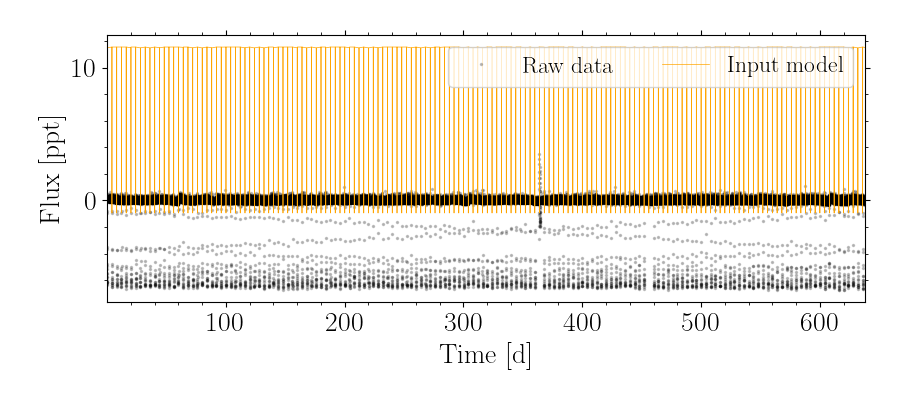

In [6]:
fig, ax = lc.plot(input_model=True, flux_unit='ppt', figsize=(9,4));
# ax.set_xlim(35, 90)
# ax.set_ylim(-34, 30)
# fig.savefig(f'{fdir}/gammaDorExample.png', bbox_inches='tight', dpi=200)

In [356]:
df = lc.data()
df = df.dropna(subset=['flux']).reset_index(drop=True)
df.flux.mean()

0.9998954100557715

## Test frequency extraction with STARSHADOW

With a PLATOnium conda environment activated, first install software using
```
pip install git+https://github.com/LucIJspeert/star_shadow
```
Open the file needed to compile the `numba` code
```
$CONDA_PREFIX/lib/python3.9/site-packages/star_shadow/run_first_use.py
```
Replace the line:
```
data_dir = script_dir.replace('star_shadow', 'data') 
```
with 
```
data_dir = os.path.join(script_dir, 'data')
```
Check that the `data` folder exists within the directory `$CONDA_PREFIX/lib/python3.9/site-packages/star_shadow`. If not, create this directory and download and place the two files `sim_000_lc.dat` and `mpl_stylesheet.dat` into this folder.

Compile the code with:
```
python $CONDA_PREFIX/lib/python3.9/site-packages/star_shadow/run_first_use.py
```
Now the code can be used.

In [226]:
import star_shadow as ss

## Compare input and output

In [439]:
# star = f'{1}'.zfill(9)
# dp = pd.read_feather(f'{path}/test_modes/varsource/{star}/varsource_001_parameters.ftr')
# df = pd.read_feather(f'{path}/test_modes/varsource/{star}/varsource_001_pulsations.ftr')
# dm = pd.read_feather(f'{path}/test_modes/finals/modes/modes_{star}.ftr')
# # df.ampl = (1 - ut.fromMagToFlux(df.ampl)) * 1e6 / dp.BC[0]
# df.ampl = df.ampl * 1e6 #/ dp.BC[0]
# dp.BC[0]

0.8673929227645699

In [491]:
star = f'{1}'.zfill(9)
dp = pd.read_feather(f'{path}/test_vsc/varsource/{star}/varsource_001_parameters.ftr')
df = pd.read_feather(f'{path}/test_vsc/varsource/{star}/varsource_001_pulsations.ftr')
dm = pd.read_feather(f'{path}/test_vsc/finals_affogato/modes/modes_{star}.ftr')
df.ampl = (1 - ut.fromMagToFlux(df.ampl)) * 1e6 / dp.BC[0]

In [492]:
# Fetch input frequencies in pettern
f_i = 1 / np.array([dp.DeltaP0_day * ((1 + dp.slope)**i - 1)/dp.slope + dp.P0_day for i in range(dp.N_modes[0])])

# Get pattern
dex_df = np.array([ut.findNearestIndex(df.freq, f_i[i]) for i in range(dp.N_modes[0])])
dex_dm = np.array([ut.findNearestIndex(dm.freq, f_i[i]) for i in range(dp.N_modes[0])])
df0 = df.loc[dex_df].reset_index(drop=True)
dm0 = dm.loc[dex_dm].reset_index(drop=True)

# O-C plot
f_oc = dm0.freq.to_numpy() - df0.freq.to_numpy()
A_oc = dm0.ampl.to_numpy() - df0.ampl.to_numpy()

# Remove matches above 0.01 c/d in the OC diagram
x = 0.0005
dex = np.where((np.abs(f_oc) > x))[0]
dm0 = dm0.drop(index=dex)
f0_oc = np.delete(f_oc, dex)
A0_oc = np.delete(A_oc, dex)

<IPython.core.display.Javascript object>


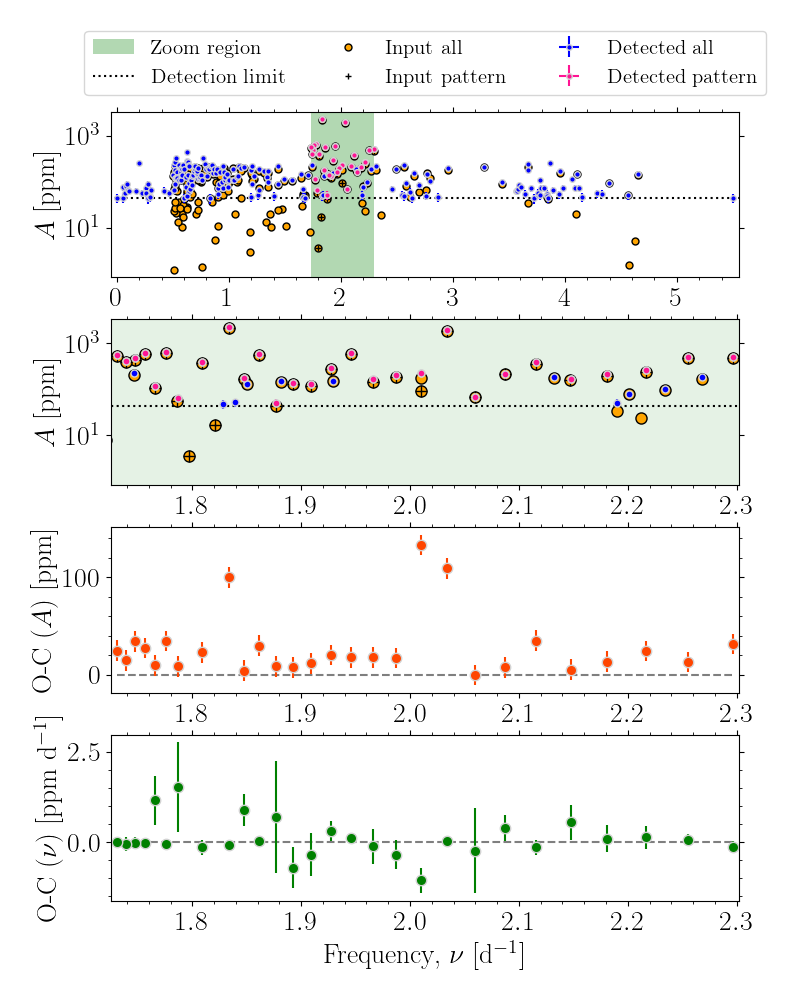

In [493]:
fig, ax = plt.subplots(4, 1, figsize=(8,10))

xlim0 = pt.getAxesMinMax(x=dm.freq.to_numpy(),  percentage=1)
xlim1 = pt.getAxesMinMax(x=dm0.freq.to_numpy(), percentage=1)

ax[0].axvspan(df0.freq.min(), df0.freq.max(), color='green', alpha=0.3, lw=0, label='Zoom region')
ax[0].axhline(y=dm.ampl.min(), xmin=xlim0[1], xmax=xlim0[0], ls=':', c='k', label='Detection limit')
ax[0].plot(df.freq,  df.ampl,  'o', ms=5, c='orange', mec='k', label='Input all')
ax[0].plot(df0.freq, df0.ampl, '+', ms=5, c='k', label='Input pattern')
ax[0].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=8, mec='lightgray', color="b", label='Detected all')
ax[0].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=8, mec='lightgray', color="deeppink", label='Detected pattern')
ax[0].legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.55), fontsize=15)
ax[0].set_ylabel(r'$A$ [ppm]')
ax[0].set_yscale('log')
ax[0].set_xlim(xlim0)

ax[1].axvspan(xlim1[0], xlim1[1], color='green', alpha=0.1, lw=0)
ax[1].axhline(y=dm.ampl.min(), xmin=xlim0[0], xmax=xlim0[1], ls=':', c='k')
ax[1].plot(df.freq,  df.ampl,  'o', ms=8, c='orange', mec='k')
ax[1].plot(df0.freq, df0.ampl, '+', ms=8, c='k')
ax[1].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=10, mec='lightgray', color="b")
ax[1].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=10, mec='lightgray', color="deeppink")
ax[1].set_ylabel(r'$A$ [ppm]')
ax[1].set_yscale('log')
ax[1].set_xlim(xlim1[1], xlim1[0])

ax[2].plot([df0.freq.min(), df0.freq.max()], [0, 0], 'k--', alpha=0.5)
ax[2].errorbar(dm0.freq, A0_oc, xerr=None, yerr=dm0.ampl_err, fmt=".", ms=15, mec='lightgray', color="orangered")
ax[2].set_ylabel(r'O-C ($A$) [ppm]')
ax[2].set_xlim(xlim1[1], xlim1[0])

ax[3].plot([df0.freq.min(), df0.freq.max()], [0, 0], 'k--', alpha=0.5)
ax[3].errorbar(dm0.freq, f0_oc*1e4, xerr=None, yerr=dm0.freq_err*1e4, fmt=".", ms=15, mec='lightgray', color="g")
ax[3].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[3].set_ylabel(r'O-C ($\nu$) [ppm d$^{-1}$]')
ax[3].set_xlim(xlim1[1], xlim1[0])

plt.tight_layout(h_pad=0.1);
# fig.savefig(f'{fdir}/FrequencyModelComparison_test0.png', bbox_inches='tight', dpi=200)

In [494]:
print(f'Stellar magnitude  : {dp.Pmag[0]:.4f} mag')
print(f'Limiting amplitude : {dm.ampl.min():.4f} ppm')
print(f'Number of modes    : {dm0.shape[0]}/{dp.N_modes[0]}')
print(f'RMS O-C amplitude  : {ut.rootMeanSquare(A0_oc):.4f} ppm')
print(f'RMS O-C frequency  : {ut.rootMeanSquare(f0_oc)*1e6:.4f} ppm/d')

Stellar magnitude  : 13.9368 mag
Limiting amplitude : 43.6781 ppm
Number of modes    : 28/30
RMS O-C amplitude  : 42.2461 ppm
RMS O-C frequency  : 51.7973 ppm/d


<IPython.core.display.Javascript object>


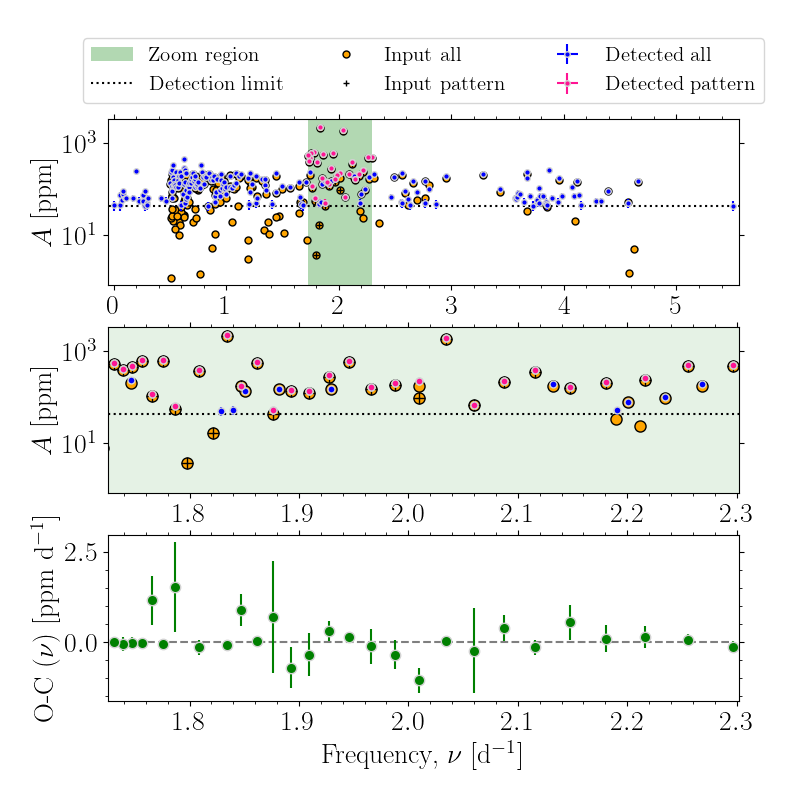

In [495]:
fig, ax = plt.subplots(3, 1, figsize=(8,8))

xlim0 = pt.getAxesMinMax(x=dm.freq.to_numpy(),  percentage=1)
xlim1 = pt.getAxesMinMax(x=dm0.freq.to_numpy(), percentage=1)

ax[0].axvspan(df0.freq.min(), df0.freq.max(), color='green', alpha=0.3, lw=0, label='Zoom region')
ax[0].axhline(y=dm.ampl.min(), xmin=xlim0[1], xmax=xlim0[0], ls=':', c='k', label='Detection limit')
ax[0].plot(df.freq,  df.ampl,  'o', ms=5, c='orange', mec='k', label='Input all')
ax[0].plot(df0.freq, df0.ampl, '+', ms=5, c='k', label='Input pattern')
ax[0].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=8, mec='lightgray', color="b", label='Detected all')
ax[0].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=8, mec='lightgray', color="deeppink", label='Detected pattern')
ax[0].legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.55), fontsize=15)
ax[0].set_ylabel(r'$A$ [ppm]')
ax[0].set_yscale('log')
ax[0].set_xlim(xlim0)

ax[1].axvspan(xlim1[0], xlim1[1], color='green', alpha=0.1, lw=0)
ax[1].axhline(y=dm.ampl.min(), xmin=xlim0[0], xmax=xlim0[1], ls=':', c='k')
ax[1].plot(df.freq,  df.ampl,  'o', ms=8, c='orange', mec='k')
ax[1].plot(df0.freq, df0.ampl, '+', ms=8, c='k')
ax[1].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=10, mec='lightgray', color="b")
ax[1].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=10, mec='lightgray', color="deeppink")
ax[1].set_ylabel(r'$A$ [ppm]')
ax[1].set_yscale('log')
ax[1].set_xlim(xlim1[1], xlim1[0])

ax[2].plot([df0.freq.min(), df0.freq.max()], [0, 0], 'k--', alpha=0.5)
ax[2].errorbar(dm0.freq, f0_oc*1e4, xerr=None, yerr=dm0.freq_err*1e4, fmt=".", ms=15, mec='lightgray', color="g")
ax[2].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[2].set_ylabel(r'O-C ($\nu$) [ppm d$^{-1}$]')
ax[2].set_xlim(xlim1[1], xlim1[0])

plt.tight_layout(h_pad=0.1);
fig.savefig(f'{fdir}/FrequencyModelComparison_test0.png', bbox_inches='tight', dpi=200)